## Laiba Ali Lab 4

## Lab 5.1

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("ai_media_dataset.csv")
df.head()

,PostID,Platform,ContentCategory,UserInterest,Likes,Comments,Shares,WatchTimeSeconds,ClickThroughRate,Impressions,PaidPromotion,AdCategory,KeywordMatchScore
0,1,Google Search,Music,Education,2964,102,628,38,0.179,35650,1,Food,0.837
1,2,Facebook,Technology,News,4002,854,520,471,0.182,26321,1,Travel,0.896
2,3,Instagram,Technology,Technology,645,802,1378,305,0.212,27160,0,Food,0.305
3,4,Facebook,News,Sports,778,339,847,306,0.355,5584,1,Electronics,0.291
4,5,Facebook,Travel,Music,1415,863,1474,416,0.303,17161,0,Electronics,0.650


In [4]:
df["EngagementScore"] = (df["Likes"] + df["Comments"] + df["Shares"])
df["EngagementScore"]

0      3694
1      5376
2      2825
3      1964
4      3752
       ... 
195    3626
196    5854
197    3887
198    6641
199    2020
Name: EngagementScore, Length: 200, dtype: int64

In [5]:
df.head()

,PostID,Platform,ContentCategory,UserInterest,Likes,Comments,Shares,WatchTimeSeconds,ClickThroughRate,Impressions,PaidPromotion,AdCategory,KeywordMatchScore,EngagementScore
0,1,Google Search,Music,Education,2964,102,628,38,0.179,35650,1,Food,0.837,3694
1,2,Facebook,Technology,News,4002,854,520,471,0.182,26321,1,Travel,0.896,5376
2,3,Instagram,Technology,Technology,645,802,1378,305,0.212,27160,0,Food,0.305,2825
3,4,Facebook,News,Sports,778,339,847,306,0.355,5584,1,Electronics,0.291,1964
4,5,Facebook,Travel,Music,1415,863,1474,416,0.303,17161,0,Electronics,0.650,3752


In [6]:
# sort the values by engagement score
df.sort_values("EngagementScore", ascending=False)

,PostID,Platform,ContentCategory,UserInterest,Likes,Comments,Shares,WatchTimeSeconds,ClickThroughRate,Impressions,PaidPromotion,AdCategory,KeywordMatchScore,EngagementScore
68,69,Google Search,Technology,Travel,4899,793,1447,511,0.101,32696,0,Electronics,0.519,7139
186,187,Facebook,Entertainment,Technology,4908,742,1488,321,0.105,46663,1,Food,0.431,7138
28,29,Google Search,Sports,Gaming,4779,856,1469,538,0.350,22010,1,Fashion,0.309,7104
32,33,Google Search,Sports,News,4896,778,1420,189,0.298,47682,0,Food,0.989,7094
132,133,Google Search,Entertainment,Gaming,4854,923,1125,124,0.449,21081,0,Food,0.219,6902
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72,73,Facebook,News,Education,505,686,338,273,0.015,45423,1,Electronics,0.258,1529
174,175,Google Search,Education,Travel,299,780,350,158,0.442,26515,0,Electronics,0.558,1429
137,138,TikTok,Technology,Technology,847,278,293,246,0.244,10268,1,Travel,0.788,1418
107,108,Google Search,News,Music,520,629,147,160,0.207,3724,1,Electronics,0.502,1296


In [7]:
#analyse the watch time
df.sort_values("WatchTimeSeconds", ascending=False)

,PostID,Platform,ContentCategory,UserInterest,Likes,Comments,Shares,WatchTimeSeconds,ClickThroughRate,Impressions,PaidPromotion,AdCategory,KeywordMatchScore,EngagementScore
64,65,TikTok,Sports,Music,4184,65,333,599,0.215,16835,1,Fashion,0.995,4582
158,159,YouTube,Music,Music,1718,149,1439,597,0.290,47719,0,Fashion,0.237,3306
90,91,Instagram,Travel,Sports,1902,798,855,588,0.146,6276,0,Travel,0.569,3555
168,169,YouTube,Sports,Gaming,4594,115,876,585,0.174,25503,0,Travel,0.228,5585
19,20,Google Search,Travel,Gaming,2988,137,472,584,0.480,38067,1,Electronics,0.251,3597
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
176,177,Instagram,Travel,Sports,4583,373,367,20,0.238,25791,1,Education,0.833,5323
83,84,Facebook,Entertainment,News,3490,550,1257,17,0.369,38658,0,Gaming,0.311,5297
105,106,Facebook,News,Travel,3380,261,1051,16,0.374,15751,0,Electronics,0.375,4692
144,145,Google Search,Travel,Technology,4998,989,810,13,0.148,30281,0,Food,0.123,6797


Practical Lab Instruction – What to do?
• Post with highest engagement: POST ID 69
• Post with highest watch time: POST ID 65
• Platform with most engaging content: I think it is POST ID 69 as it has the highest engagement score.

What You Will Learn: How platforms measure engagement, How AI identifies popular content
Deliverables
Screenshot showing engagement score. Table can be seen above
Student Tasks: Answer:
• Which post has highest engagement?
POST ID 69
• Why would AI recommend this post?
Becasue this has highes engagement score which is the sum of likes, shares and comments.

Expected Discussion on the Lab
Platforms track engagement to decide what content to recommend.
Practical Lab Reflection Questions
• Why do platforms track engagement?

They track engagement because they want to target the users for their advertisement and keeping the user entertained. 

## Lab 5.2: Building a Content Recommendation Algorithm

In [8]:
df["RecommendationScore"] = ( df["Likes"] * 0.3 + df["Comments"] * 0.2 + df["Shares"] * 0.3 + df["WatchTimeSeconds"] * 0.1 + df["ClickThroughRate"] * 100 * 0.1)
df["RecommendationScore"]

0      1103.59
1      1576.32
2       799.92
3       589.45
4      1083.93
        ...   
195    1094.29
196    1710.79
197    1156.52
198    1971.02
199     600.42
Name: RecommendationScore, Length: 200, dtype: float64

In [9]:
#sort recommended content
recommended = df.sort_values("RecommendationScore", ascending=False)
recommended.head(10)

,PostID,Platform,ContentCategory,UserInterest,Likes,Comments,Shares,WatchTimeSeconds,ClickThroughRate,Impressions,PaidPromotion,AdCategory,KeywordMatchScore,EngagementScore,RecommendationScore
68,69,Google Search,Technology,Travel,4899,793,1447,511,0.101,32696,0,Electronics,0.519,7139,2114.51
28,29,Google Search,Sports,Gaming,4779,856,1469,538,0.350,22010,1,Fashion,0.309,7104,2102.90
186,187,Facebook,Entertainment,Technology,4908,742,1488,321,0.105,46663,1,Food,0.431,7138,2100.35
32,33,Google Search,Sports,News,4896,778,1420,189,0.298,47682,0,Food,0.989,7094,2072.28
122,123,Facebook,Sports,Gaming,4885,390,1476,265,0.267,37435,1,Food,0.811,6751,2015.47
132,133,Google Search,Entertainment,Gaming,4854,923,1125,124,0.449,21081,0,Food,0.219,6902,1995.19
162,163,Facebook,Music,Music,4859,584,1320,177,0.370,33357,1,Food,0.152,6763,1991.90
91,92,YouTube,News,News,4960,253,1407,60,0.456,36944,0,Food,0.661,6620,1971.26
198,199,Facebook,Music,Education,4909,714,1018,459,0.422,46526,1,Food,0.582,6641,1971.02
144,145,Google Search,Travel,Technology,4998,989,810,13,0.148,30281,0,Food,0.123,6797,1942.98


Deliverables: Screenshot showing recommendations.

Student Tasks: Explain why these posts were recommended.
They are recommended based on the engagement score.

Expected Discussion on the Lab: AI recommends high engagement content.
Practical Lab Reflection Questions: Why does TikTok recommend viral content?
Because of th engagement score. Also, many other users are sharing it among themselves and posting it as well. Once there are many shares and likes etc TikTok it self starts to recommend it to other users. This is like a loop.

## Lab 5.3: Creating a Personalised Recommendation System

In [10]:
#filter user interest
sports_content = df[df["UserInterest"] == "Sports"]
#sort recommended sports content
sports_content.sort_values("RecommendationScore", ascending=False)


,PostID,Platform,ContentCategory,UserInterest,Likes,Comments,Shares,WatchTimeSeconds,ClickThroughRate,Impressions,PaidPromotion,AdCategory,KeywordMatchScore,EngagementScore,RecommendationScore
67,68,TikTok,Entertainment,Sports,4798,407,915,203,0.010,34950,1,Electronics,0.758,6120,1815.70
176,177,Instagram,Travel,Sports,4583,373,367,20,0.238,25791,1,Education,0.833,5323,1563.98
166,167,Google Search,Music,Sports,4830,113,15,485,0.087,605,0,Food,0.985,4958,1525.47
179,180,YouTube,Music,Sports,4012,558,145,196,0.412,3889,0,Gaming,0.662,4715,1382.42
102,103,Google Search,Technology,Sports,3634,341,620,174,0.304,42152,1,Travel,0.179,4595,1364.84
70,71,YouTube,Technology,Sports,3759,470,322,123,0.467,7924,1,Electronics,0.606,4551,1335.27
141,142,Facebook,Entertainment,Sports,3186,887,521,287,0.171,49090,0,Education,0.232,4594,1319.91
43,44,TikTok,Entertainment,Sports,3286,765,536,157,0.375,24150,0,Gaming,0.621,4587,1319.05
189,190,Instagram,Sports,Sports,2864,319,1012,157,0.284,12153,0,Education,0.760,4195,1245.14
59,60,TikTok,Entertainment,Sports,2973,199,902,295,0.334,48351,1,Food,0.686,4074,1235.14


In [11]:
#Repeat for Music
#filter user interest
music_content = df[df["UserInterest"] == "Music"]
#sort recommended Music content
music_content.sort_values("RecommendationScore", ascending=False)

,PostID,Platform,ContentCategory,UserInterest,Likes,Comments,Shares,WatchTimeSeconds,ClickThroughRate,Impressions,PaidPromotion,AdCategory,KeywordMatchScore,EngagementScore,RecommendationScore
162,163,Facebook,Music,Music,4859,584,1320,177,0.370,33357,1,Food,0.152,6763,1991.90
14,15,Google Search,News,Music,4996,546,552,146,0.481,21453,1,Gaming,0.701,6094,1793.01
188,189,YouTube,Entertainment,Music,4769,956,360,557,0.170,1399,1,Education,0.845,6085,1787.30
116,117,TikTok,Education,Music,4235,530,1067,395,0.415,5609,1,Gaming,0.205,5832,1740.25
61,62,Google Search,Sports,Music,4236,97,1196,433,0.265,32847,1,Fashion,0.392,5529,1694.95
9,10,Facebook,Technology,Music,4410,253,903,10,0.484,7991,0,Education,0.313,5566,1650.34
169,170,Google Search,Sports,Music,4633,232,554,139,0.127,6590,0,Fashion,0.209,5419,1617.67
130,131,Instagram,Technology,Music,4535,7,554,68,0.376,22304,0,Electronics,0.677,5096,1538.66
154,155,Instagram,Technology,Music,4663,478,51,43,0.040,47324,0,Food,0.677,5192,1514.50
64,65,TikTok,Sports,Music,4184,65,333,599,0.215,16835,1,Fashion,0.995,4582,1430.15


In [14]:
#Repeat for Technology
#Repeat for Music
#filter user interest
music_content = df[df["UserInterest"] == "Technology"]
#sort recommended Music content
music_content.sort_values("RecommendationScore", ascending=False)

,PostID,Platform,ContentCategory,UserInterest,Likes,Comments,Shares,WatchTimeSeconds,ClickThroughRate,Impressions,PaidPromotion,AdCategory,KeywordMatchScore,EngagementScore,RecommendationScore
186,187,Facebook,Entertainment,Technology,4908,742,1488,321,0.105,46663,1,Food,0.431,7138,2100.35
144,145,Google Search,Travel,Technology,4998,989,810,13,0.148,30281,0,Food,0.123,6797,1942.98
18,19,YouTube,News,Technology,4541,85,1350,126,0.052,24321,0,Food,0.628,5976,1797.42
140,141,YouTube,News,Technology,4519,743,602,210,0.027,39059,0,Fashion,0.459,5864,1706.17
155,156,YouTube,Music,Technology,4621,130,328,26,0.443,45504,0,Food,0.294,5079,1517.73
165,166,TikTok,Music,Technology,4196,237,73,410,0.130,3541,1,Travel,0.726,4506,1370.40
117,118,Instagram,Entertainment,Technology,3769,478,202,480,0.402,49768,0,Fashion,0.836,4449,1338.92
34,35,Instagram,Travel,Technology,2589,454,1463,170,0.282,27582,1,Food,0.726,4506,1326.22
136,137,Google Search,Sports,Technology,2921,512,955,561,0.144,46667,1,Education,0.646,4388,1322.74
127,128,Google Search,Education,Technology,3006,316,927,373,0.450,41625,1,Food,0.725,4249,1284.90


In [15]:
#Travel
#Repeat for Music
#filter user interest
music_content = df[df["UserInterest"] == "Travel"]
#sort recommended Music content
music_content.sort_values("RecommendationScore", ascending=False)

,PostID,Platform,ContentCategory,UserInterest,Likes,Comments,Shares,WatchTimeSeconds,ClickThroughRate,Impressions,PaidPromotion,AdCategory,KeywordMatchScore,EngagementScore,RecommendationScore
68,69,Google Search,Technology,Travel,4899,793,1447,511,0.101,32696,0,Electronics,0.519,7139,2114.51
52,53,Google Search,News,Travel,4362,904,849,444,0.444,23911,1,Gaming,0.162,6115,1792.94
88,89,Google Search,Education,Travel,3677,927,1193,248,0.361,22063,1,Food,0.586,5797,1674.81
147,148,Instagram,Travel,Travel,4834,32,232,118,0.351,35988,1,Food,0.595,5098,1541.51
146,147,Google Search,Education,Travel,3975,489,819,38,0.012,49287,1,Travel,0.967,5283,1539.92
121,122,Google Search,News,Travel,4186,220,558,270,0.303,20672,0,Travel,0.825,4964,1497.23
95,96,Instagram,News,Travel,4348,243,136,97,0.071,17934,1,Gaming,0.843,4727,1404.21
26,27,Instagram,Travel,Travel,3032,789,951,427,0.453,35696,1,Food,0.646,4772,1399.93
105,106,Facebook,News,Travel,3380,261,1051,16,0.374,15751,0,Electronics,0.375,4692,1386.84
193,194,TikTok,News,Travel,4031,381,131,516,0.411,34162,1,Electronics,0.533,4543,1380.51


Explain personalisation.

Practical Lab Reflection Questions:

• Why does YouTube recommend different videos to different users?

Youtube Recommend differnet videos to different users based on their personal data like which videos they like share and comment on and what kind of content they prefer watching. For example, if I serach for videos related to CS, I will get recommended videos of Google, Apple, or othe rinformative videos or padcasts. This is to keep the users engage and no let them Churn (quit visititng the platform) or get bored.


### 5.4 Simulating Search Engine Ranking Algorithm (SEO and Paid Ads)

In [16]:
# Create a search ranking score
df["SearchRankingScore"] = (
df["KeywordMatchScore"] * 0.5 +
df["ClickThroughRate"] * 0.3 +
df["PaidPromotion"] * 0.2
    )

In [17]:
# Sort results
df.sort_values("SearchRankingScore", ascending=False)

,PostID,Platform,ContentCategory,UserInterest,Likes,Comments,Shares,WatchTimeSeconds,ClickThroughRate,Impressions,PaidPromotion,AdCategory,KeywordMatchScore,EngagementScore,RecommendationScore,SearchRankingScore
175,176,TikTok,Music,Gaming,723,940,306,305,0.481,33820,1,Food,0.997,1969,532.01,0.8428
115,116,Facebook,Sports,Music,1195,730,108,532,0.479,9708,1,Gaming,0.938,2033,594.89,0.8127
103,104,TikTok,Technology,News,1446,30,804,191,0.453,6155,1,Education,0.943,2280,704.63,0.8074
87,88,YouTube,Technology,Gaming,2155,817,729,63,0.428,34875,1,Fashion,0.934,3701,1039.18,0.7954
110,111,YouTube,Education,Travel,2881,696,149,390,0.417,29041,1,Education,0.927,3726,1091.37,0.7886
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,174,Google Search,Travel,Technology,1624,627,819,38,0.103,40185,0,Fashion,0.156,3070,863.13,0.1089
98,99,TikTok,Travel,Music,3562,111,93,129,0.137,31207,0,Electronics,0.133,3766,1132.97,0.1076
144,145,Google Search,Travel,Technology,4998,989,810,13,0.148,30281,0,Food,0.123,6797,1942.98,0.1059
92,93,Instagram,Sports,News,4225,51,82,273,0.032,3880,0,Travel,0.180,4358,1329.92,0.0996


• Identify top ranked content. POST AD 176, Platform: TikTok

Student Tasks: Explain ranking logic.

Practical Lab Reflection Questions: Why do some websites appear first?

Based on my personal search it follows Markov chains principle. I am also studying it by myself so I won't talk about it more. But another reason is the rating that the pages have. SO pages with more clicks have more engagement so they appear at the top.
Also they best match the user's search and are highly relevant to what they need. They aslo ahve authoritative, and trustworthy content. Top ranking sites are optimized for speed, mobile-friendliness, and user experience, and they often have high-quality backlinks.

### Lab 5.5: Simulating Advertisement Targeting Algorithm

In [18]:
# Filter high click rate users
high_ctr = df[df["ClickThroughRate"] > 0.3]

In [19]:
# View ad categories
high_ctr[["UserInterest", "AdCategory"]]

,UserInterest,AdCategory
3,Sports,Electronics
4,Music,Electronics
9,Music,Education
13,Gaming,Travel
14,Music,Gaming
...,...,...
179,Sports,Gaming
181,Music,Education
184,Technology,Electronics
193,Travel,Electronics


Student Tasks: Explain ad targeting.

Practical Lab Reflection Questions: Why do ads follow users?

They are programmed in a way that users will find the ads for which they have previously search or seen.
For more technical anser, I did some search and found this:
Ads follow users because of a marketing strategy called retargeting. When a user visits a website, a small piece of code called a tracking pixel saves an anonymous cookie in your browser. This "tags" you as someone interested in a specific product, and when you move to other sites, ad networks recognize that tag and show you relevant ads to encourage a purchase.

### Lab 5.6: Predicting Viral Content using AI Logic

In [20]:
# Identify viral posts
viral = df[df["RecommendationScore"] > 1000]
# View viral posts
viral

,PostID,Platform,ContentCategory,UserInterest,Likes,Comments,Shares,WatchTimeSeconds,ClickThroughRate,Impressions,PaidPromotion,AdCategory,KeywordMatchScore,EngagementScore,RecommendationScore,SearchRankingScore
0,1,Google Search,Music,Education,2964,102,628,38,0.179,35650,1,Food,0.837,3694,1103.59,0.6722
1,2,Facebook,Technology,News,4002,854,520,471,0.182,26321,1,Travel,0.896,5376,1576.32,0.7026
4,5,Facebook,Travel,Music,1415,863,1474,416,0.303,17161,0,Electronics,0.650,3752,1083.93,0.4159
5,6,TikTok,Sports,Education,4542,439,354,414,0.235,14007,0,Travel,0.470,5335,1600.35,0.3055
8,9,Instagram,News,News,4221,312,763,191,0.011,46039,1,Fashion,0.418,5296,1576.81,0.4123
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
194,195,Google Search,Travel,Gaming,4723,293,1134,374,0.073,33782,0,Education,0.117,6150,1853.83,0.0804
195,196,Instagram,Travel,Sports,2172,441,1013,491,0.149,21788,0,Food,0.334,3626,1094.29,0.2117
196,197,Instagram,Entertainment,Education,4580,666,608,210,0.019,30045,0,Fashion,0.784,5854,1710.79,0.3977
197,198,YouTube,Music,Travel,2200,281,1406,163,0.222,37377,0,Travel,0.223,3887,1156.52,0.1781


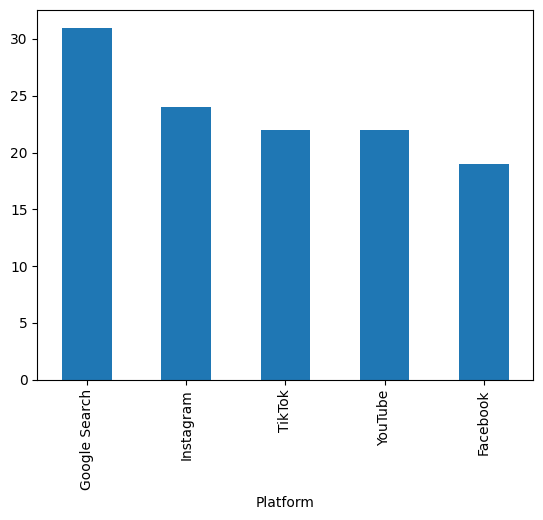

In [22]:
# Plot viral content
viral["Platform"].value_counts().plot(kind="bar")
plt.show()

Identify platforms producing viral content. As we can see from above chart it is Google Search

Practical Lab Reflection Questions: Why do some posts go viral?

Because fo the users. I mean it really depends what kind of content is that and who the audience are. For example, a celebrity making a Tik Tok or any drama on YouTube or any post of a celebrity of influncer on Instagram or Tweet or Elon Must on X. It all depends how they are influences people and how users are likin, sharing and commenting on that videos posts etc. It also depends on based on the engagement how the paltforms algorithm is recommending it to others.